# Tariff Inversion Analysis of 2025 HTS

A tariff inversion is when a raw material is taxed **higher** than the finished good made from it.  
This penalizes domestic manufacturers and it becomes cheaper to import the finished product than to make it here.


*Author : Ari Munkhtur*

*Email  : am5663@drexel.edu*


## 1. Imports

In [32]:
import pandas as pd


## 2. Load and Prep Data

2025 HTS
HTS or Harmonized Tariff Schedule has 13058 product codes covering everything imported into the United States.

In order to correctly analyze clean inversions, we cleaned the data according to these key decisions

**Decisions**
- Keep only ad valorem rates or percentage based rates. Some items use specific rates like "$1.20 per kg". We cant compare those to percentages, so we are dropping them for now. 
- Drop rates where the rate is missing or clearly too big that it becomes an outlier. 
- Remove chapter 98 and 99. Those are special chapters not real product groups. 

In [15]:
df = pd.read_csv("hts_cleaned.csv", low_memory=False, dtype={"hts8": str})

# Keep only percentage based rates [ can't compare $/kg to % ]
# We only want the items that have ad valorem rates and make sure that we have actual numeric values instead of placeholders.
df = df[df["has_adval"] == True].copy()
df["rate_clean"] = pd.to_numeric(df["rate_clean"], errors="coerce")
df = df[df["rate_clean"].notna() & (df["rate_clean"] < 999)]

# Extract chapter and lowercase descriptions
df["hts_str"]    = df["hts8"].astype(str).str.zfill(8)
df["chapter"]    = df["hts_str"].str[:2] # First 2 digits are the chapter
df["desc_lower"] = df["brief_description"].str.lower().fillna("")   

# Remove special/administrative chapters
# Those are special purpose chapters we dont need those. 
df = df[~df["chapter"].isin(["98", "99"])]

print(f"Loaded {len(df):,} usable HTS items")

Loaded 6,192 usable HTS items


After cleaning the data we should have row for each HTS product code.
Important columns are : 
- hts8 (unique 8 digit product ID)
- brief_description ( plain english product name) 
- rate_clean ( MFN tariff rate as decimal) 
- chapter (first 2 digits of the HTS code for related products)

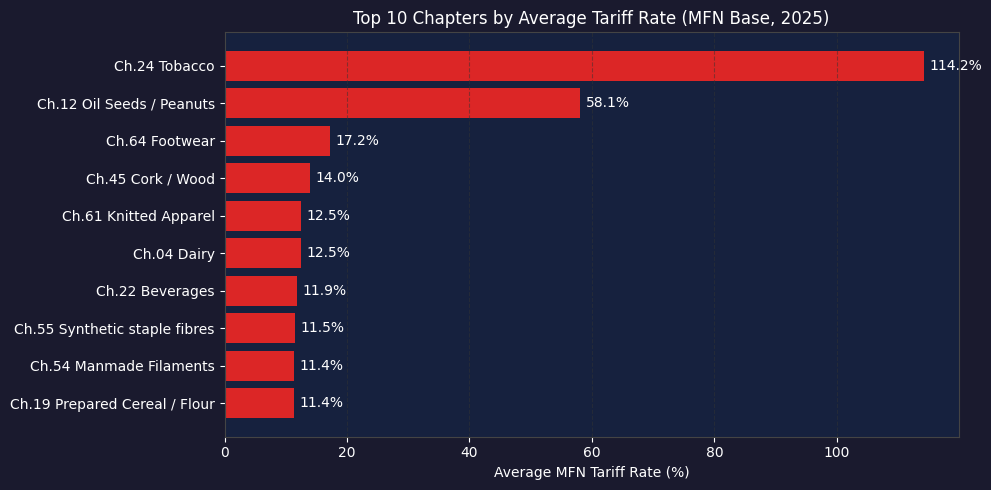

In [17]:
import matplotlib.pyplot as plt

# Top 10 chapters by average tariff rate
chapter_avg = (
    df[df["rate_clean"] > 0]
    .groupby("chapter")["rate_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

chapter_labels = {
    "24": "Ch.24 Tobacco",
    "12": "Ch.12 Oil Seeds / Peanuts",
    "64": "Ch.64 Footwear",
    "61": "Ch.61 Knitted Apparel",
    "62": "Ch.62 Woven Apparel",
    "04": "Ch.04 Dairy",
    "17": "Ch.17 Sugar",
    "20": "Ch.20 Prepared Vegetables",
    "63": "Ch.63 Other Textiles",
    "16": "Ch.16 Prepared Meat / Fish",
    "45": "Ch.45 Cork / Wood",
    "22": "Ch.22 Beverages",
    "55": "Ch.55 Synthetic staple fibres",
    "54": "Ch.54 Manmade Filaments",
    "19": "Ch.19 Prepared Cereal / Flour",
}

labels = [chapter_labels.get(ch, f"Ch.{ch}") for ch in chapter_avg.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], chapter_avg.values[::-1], color="#DC2626")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_xlabel("Average MFN Tariff Rate (%)")
ax.set_title("Top 10 Chapters by Average Tariff Rate (MFN Base, 2025)")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Supply Chain Map

To find inversions in the supply chain, we need to connect raw materials to finished products. We will do this by using keyword matching on HTS product descriptions. 

**Why keyword matching?**

The HTS has no built in supply chain relationship map. It is just flat list of products. Therefore we had to build those connections. 
Keyword matching is simple, and transparent. However, the tradeoff is blind spots where raw material description that doesnt fit the desciprtion of the finished product. We will miss that relationship completely. 

**6 Industries** 

From outside qualitative research, I concluded that industries such as *food processing, electronics, apparel, automotive, leather and metals* will  have highest and most impactful inversion. 


**Industry supply chain validation**

To make sure our keyword matches reflect real supply chain relationship and not just description coincidence or false positives, we verified every pair against the **BEA 2017 Input-Output Use Table**. 
The BEA data gives a tabular data on which industries buy from each other. A supply chain pair was confirmed if BEA recorded at least $100M in flows between two industries. 
 


Each rule defines a raw material → finished good relationship.  
Format: `(industry, raw_chapter, finished_chapter, raw_keywords, finished_keywords)`


In [ ]:
SUPPLY_CHAINS = [
    # INDUSTRY     |RAW_CHAPTER |FINISHED_CHAPTER| KEYWORDS (RAW)                      | KEYWORDS (FINISHED)  
    # Food
    ("Food Processing",    "12", "20", ["peanut", "groundnut"],              ["peanut butter", "peanut paste"]),
    ("Food Processing",    "02", "16", ["beef", "bovine"],                   ["beef", "bovine"]),
    ("Food Processing",    "02", "16", ["pork", "swine", "pig"],             ["pork", "ham", "bacon"]),
    ("Food Processing",    "02", "16", ["chicken", "poultry"],               ["chicken", "poultry", "fowl"]),
    ("Food Processing",    "03", "16", ["fish", "tuna", "salmon", "cod"],    ["fish", "tuna", "salmon", "sardine"]),
    ("Food Processing",    "07", "20", ["tomato"],                           ["tomato"]),
    ("Food Processing",    "07", "20", ["onion"],                            ["onion"]),
    ("Food Processing",    "07", "20", ["garlic"],                           ["garlic"]),
    ("Food Processing",    "10", "19", ["wheat"],                            ["bread", "pasta", "noodle", "biscuit"]),
    ("Food Processing",    "10", "19", ["rice"],                             ["rice"]),

    # Electronics
    ("Electronics",        "39", "84", ["polyethylene", "polypropylene", "pvc"], ["computer", "laptop", "printer", "machine"]),
    ("Electronics",        "39", "85", ["polyethylene", "polypropylene", "pvc"], ["telephone", "phone", "circuit", "semiconductor"]),
    ("Electronics",        "29", "85", ["silicon", "silicone"],              ["semiconductor", "circuit", "transistor"]),
    ("Electronics",        "74", "85", ["copper", "wire"],                   ["cable", "wire", "conductor"]),
    ("Electronics",        "76", "84", ["aluminum", "aluminium"],            ["computer", "machine", "processor"]),

    # Apparel
    ("Apparel & Textiles", "52", "61", ["cotton"],                           ["cotton", "shirt", "blouse", "sweater"]),
    ("Apparel & Textiles", "52", "62", ["cotton"],                           ["cotton", "trouser", "jacket", "suit"]),
    ("Apparel & Textiles", "51", "61", ["wool"],                             ["wool", "cashmere", "fine animal"]),
    ("Apparel & Textiles", "54", "61", ["filament", "nylon", "polyester"],   ["manmade", "man-made", "synthetic"]),

    # Automotive
    ("Automotive",         "72", "87", ["steel", "iron", "rod", "bar"],      ["vehicle", "car", "truck", "automobile"]),
    ("Automotive",         "40", "87", ["rubber", "tyre", "tire"],           ["vehicle", "car", "truck", "tyre"]),

    # Leather
    ("Leather & Footwear", "41", "64", ["hide", "skin", "leather"],          ["leather", "footwear", "shoe", "boot"]),
    ("Leather & Footwear", "41", "42", ["hide", "skin", "leather"],          ["handbag", "wallet", "belt", "leather"]),

    # Metals
    ("Metal Products",     "72", "73", ["steel", "iron", "wire", "sheet"],   ["tube", "pipe", "structure", "article"]),
    ("Metal Products",     "74", "83", ["copper"],                           ["copper", "lock", "fitting"]),
]

In [31]:
# Display supply chain rules as a summary table
sc_df = pd.DataFrame(SUPPLY_CHAINS, columns=[
    "Industry", "Raw Chapter", "Finished Chapter", "Raw Keywords", "Finished Keywords"
])
sc_df["Raw Keywords"] = sc_df["Raw Keywords"].apply(lambda x: ", ".join(x))
sc_df["Finished Keywords"] = sc_df["Finished Keywords"].apply(lambda x: ", ".join(x))

print(f"Total rules: {len(sc_df)}")
print(f"Industries:  {sc_df['Industry'].nunique()}\n")
sc_df

Total rules: 25
Industries:  6



,Industry,Raw Chapter,Finished Chapter,Raw Keywords,Finished Keywords
0,Food Processing,12,20,"peanut, groundnut","peanut butter, peanut paste"
1,Food Processing,02,16,"beef, bovine","beef, bovine"
2,Food Processing,02,16,"pork, swine, pig","pork, ham, bacon"
3,Food Processing,02,16,"chicken, poultry","chicken, poultry, fowl"
4,Food Processing,03,16,"fish, tuna, salmon, cod","fish, tuna, salmon, sardine"
5,Food Processing,07,20,tomato,tomato
6,Food Processing,07,20,onion,onion
7,Food Processing,07,20,garlic,garlic
8,Food Processing,10,19,wheat,"bread, pasta, noodle, biscuit"
9,Food Processing,10,19,rice,rice


**Data used for supply chain relationship verification**


In [30]:
import pandas as pd
import openpyxl

# Load the BEA table
bea = pd.read_excel("IOUse_Before_Redefinitions_PRO_Detail.xlsx", 
                    sheet_name="2017", 
                    header=4, 
                    index_col=0)

print(f"BEA IO Table shape: {bea.shape}")
snippet = bea.iloc[:15, :15]
snippet.index.name = "Industry row"
snippet.columns.name = "Industry column"
snippet

BEA IO Table shape: (409, 426)


Industry column,Unnamed: 1,Oilseed farming,Grain farming,Vegetable and melon farming,Fruit and tree nut farming,"Greenhouse, nursery, and floriculture production",Other crop farming,Dairy cattle and milk production,"Beef cattle ranching and farming, including feedlots and dual-purpose ranching and farming",Poultry and egg production,"Animal production, except cattle and poultry and eggs",Forestry and logging,"Fishing, hunting and trapping",Support activities for agriculture and forestry,Oil and gas extraction
Industry row,,,,,,,,,,,,,,,
Code,Commodity Description,1111A0,1111B0,111200.0,111300.0,111400.0,111900.0,112120.0,1121A0,112300.0,112A00,113000.0,114000.0,115000.0,211000.0
1111A0,Oilseed farming,8332,455,40.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1111B0,Grain farming,NaN,7694,NaN,NaN,NaN,446.0,1697.0,4253,1597.0,175,NaN,NaN,NaN,NaN
111200,Vegetable and melon farming,NaN,NaN,666.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111300,Fruit and tree nut farming,NaN,NaN,NaN,748.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111400,"Greenhouse, nursery, and floriculture production",NaN,NaN,NaN,NaN,2623.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0,NaN
111900,Other crop farming,160,487,NaN,NaN,0.0,935.0,332.0,379,NaN,18,NaN,NaN,NaN,NaN
112120,Dairy cattle and milk production,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN
1121A0,"Beef cattle ranching and farming, including fe...",32,211,18.0,72.0,19.0,25.0,2660.0,32546,NaN,625,NaN,NaN,36.0,NaN


## 4. Find Inversions

Now we run the main code. For each supply chain we : 
 - filter the HTS items matching the raw material keywords in the raw chapter
 - filter the HTS items matching the finished goods keywords in the finished chapter
 - compare every raw item against every finished item
 - keep pairs where raw rate is higher than the finished rate meaning the inversion
 
 The gap measured is in percentage points. A gap of 10 points means the raw material is taxed at 10 percentage points higher thant the finished good made from it. 

In [36]:
def match(desc, keywords):
    return any(kw in desc for kw in keywords)

inversions = []

for industry, raw_ch, fin_ch, raw_kws, fin_kws in SUPPLY_CHAINS:

    raw_items = df[df["chapter"] == raw_ch]
    fin_items = df[df["chapter"] == fin_ch]

    raw_matched = raw_items[raw_items["desc_lower"].apply(lambda d: match(d, raw_kws))]
    fin_matched = fin_items[fin_items["desc_lower"].apply(lambda d: match(d, fin_kws))]

    for _, raw in raw_matched.iterrows():
        for _, fin in fin_matched.iterrows():
            gap = raw["rate_clean"] - fin["rate_clean"]
            if gap > 0:  # inversion found
                inversions.append({
                    "industry":      industry,
                    "raw_hts":       raw["hts_str"],
                    "raw_item":      raw["brief_description"],
                    "raw_rate":      round(raw["rate_clean"] * 100, 2),
                    "finished_hts":  fin["hts_str"],
                    "finished_item": fin["brief_description"],
                    "finished_rate": round(fin["rate_clean"] * 100, 2),
                    "gap_pts":       round(gap * 100, 2),
                })

results = pd.DataFrame(inversions)

# Keep worst gap per unique raw to finished pair, then one row per raw item
results = results.sort_values("gap_pts", ascending=False)
results = results.drop_duplicates(subset=["raw_hts", "finished_hts"]) # keep worst gap per unique raw to finished pair
results = results.drop_duplicates(subset=["raw_hts"])       # then keep worst gap per raw item  
results = results.reset_index(drop=True)

print(f"Found {len(results):,} raw items with at least one tariff inversion")
results.head(5)

Found 682 raw items with at least one tariff inversion


,industry,raw_hts,raw_item,raw_rate,finished_hts,finished_item,finished_rate,gap_pts
0,Food Processing,12024180,"Peanuts (ground-nuts), not seed, not roasted o...",163.8,20081115,"Peanut butter and paste, nesoi, not subject to...",131.8,32.0
1,Food Processing,07122020,Dried onion powder or flour,29.8,20019034,"Onions, prepared or preserved by vinegar or ac...",3.6,26.2
2,Food Processing,02023080,"Bovine meat cuts, boneless, frozen, not descr ...",26.4,16025021,"Of bovine animals, other, in airtight containers",1.4,25.0
3,Food Processing,02013080,"Bovine meat cuts, boneless, fresh or chld., no...",26.4,16025021,"Of bovine animals, other, in airtight containers",1.4,25.0
4,Food Processing,02011050,"Bovine carcasses and halves, fresh or chld., o...",26.4,16025021,"Of bovine animals, other, in airtight containers",1.4,25.0


The 682 pairs are a conservative lower bound. The algorithm found inversions across many raw to finished combinations. We are only keeping only single worst inversions per raw material. 
Expanding the supply chain rules to more industries and more keyword relationship would likely surface significantly more inverted pairs

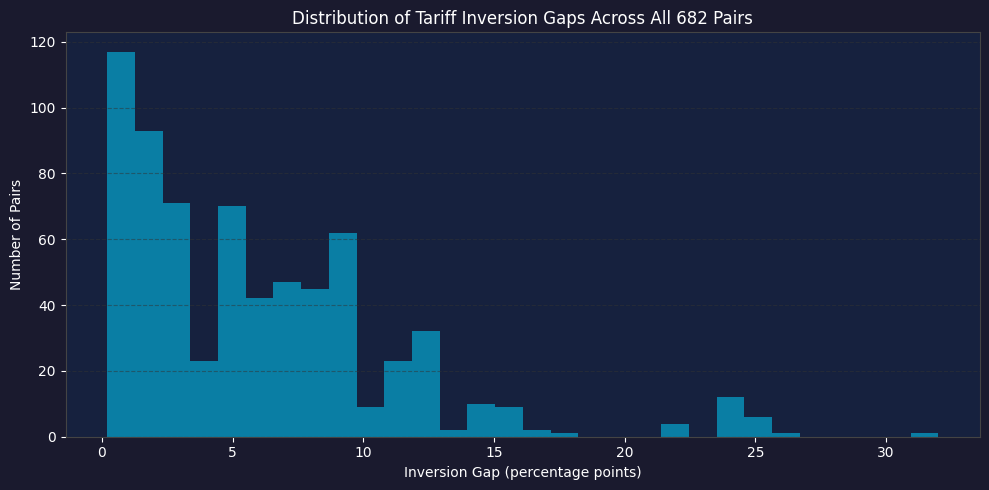

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(results["gap_pts"], bins=30, color="#0A7EA4", edgecolor="none")
ax.set_xlabel("Inversion Gap (percentage points)")
ax.set_ylabel("Number of Pairs")
ax.set_title("Distribution of Tariff Inversion Gaps Across All 682 Pairs")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### What the distribution tells us

The histogram is right skewed meaning most inversions are small but few are exteme outliers. 

This means that inversion problem is widespread and it exists across hundres of pairs in every industry. 
But handful pairs have very large inversions. 

This also means that inversions are not concentrated in only one industry but consistent across 6 industries. If we increase our industry scope and verify every supply chain pairs in the US indsutry we will find more of these inversions. 

## 5. All Inversions — Sorted by Gap (Highest to Lowest)

Here we print every inversion from largest gap to smallest. 
A large gap means more penalty for domestic manufacturer importing raw material into the US. 

In [59]:
print("=" * 70)
print("= Top 10  INVERSIONS : sorted by gap from highest to lowest          = ")
print("=" * 70)

for i, row in results.head(5).iterrows(): # only show top 5
    print(f"\n#{i+1}  [{row['industry']}]  GAP: +{row['gap_pts']} pts")
    print(f"  RAW      [{row['raw_hts']}]  {row['raw_item'][:70]}")
    print(f"           Tariff: {row['raw_rate']}%")
    print(f"  FINISHED [{row['finished_hts']}]  {row['finished_item'][:70]}")
    print(f"           Tariff: {row['finished_rate']}%")

= Top 10  INVERSIONS : sorted by gap from highest to lowest          = 

#1  [Food Processing]  GAP: +32.0 pts
  RAW      [12024180]  Peanuts (ground-nuts), not seed, not roasted or cooked, in shell, not 
           Tariff: 163.8%
  FINISHED [20081115]  Peanut butter and paste, nesoi, not subject to gen note 15 or add US n
           Tariff: 131.8%

#2  [Food Processing]  GAP: +26.2 pts
  RAW      [07122020]  Dried onion powder or flour
           Tariff: 29.8%
  FINISHED [20019034]  Onions, prepared or preserved by vinegar or acetic acid
           Tariff: 3.6%

#3  [Food Processing]  GAP: +25.0 pts
  RAW      [02023080]  Bovine meat cuts, boneless, frozen, not descr in gen. note 15 or add. 
           Tariff: 26.4%
  FINISHED [16025021]  Of bovine animals, other, in airtight containers
           Tariff: 1.4%

#4  [Food Processing]  GAP: +25.0 pts
  RAW      [02013080]  Bovine meat cuts, boneless, fresh or chld., not descr in gen. note 15 
           Tariff: 26.4%
  FINISHED [1602502

### The pattern
Every single one of these represents domestic manufacturer at structural disadvantage. They pay more to import their raw materials than a foreign competitor pays to ship their finished goods. 

This pattern exists across all 6 industries. 

## 6. Industry Summary

Now aggregate the pairs by industry to understand where inversions are most severe and common. 

Per industry we have: 
- Total inversions
- Average gap 
- Max gap

In [55]:
print("=" * 70)
print("=  INDUSTRIES : sorted by number of inversions (highest to lowest)   =")
print("=" * 70 + "\n")

industry_summary = (
    results.groupby("industry")
    .agg(
        total_inversions=("gap_pts", "count"),
        avg_gap=("gap_pts", "mean"),
        max_gap=("gap_pts", "max")
    )
    .sort_values("total_inversions", ascending=False)
    .reset_index()
)

for _, row in industry_summary.iterrows():
    print(f"  {row['industry']:<22}  {row['total_inversions']:>4} inversions  "
          f"avg gap: {row['avg_gap']:.1f} pts  max gap: {row['max_gap']:.1f} pts")

=  INDUSTRIES : sorted by number of inversions (highest to lowest)   =

  Apparel & Textiles       349 inversions  avg gap: 9.0 pts  max gap: 24.2 pts
  Leather & Footwear        92 inversions  avg gap: 1.4 pts  max gap: 3.2 pts
  Automotive                87 inversions  avg gap: 2.5 pts  max gap: 12.6 pts
  Electronics               69 inversions  avg gap: 3.3 pts  max gap: 5.5 pts
  Metal Products            51 inversions  avg gap: 0.9 pts  max gap: 1.0 pts
  Food Processing           34 inversions  avg gap: 10.1 pts  max gap: 32.0 pts


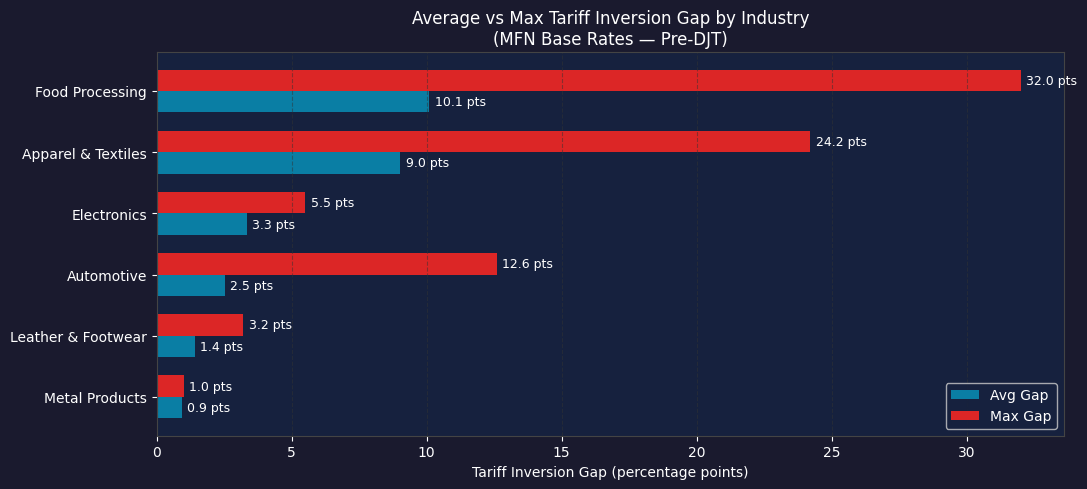

In [46]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))

summary_sorted = industry_summary.sort_values("avg_gap", ascending=True)
y = np.arange(len(summary_sorted))
height = 0.35

bars1 = ax.barh(y - height/2, summary_sorted["avg_gap"], height,
                color="#0A7EA4", label="Avg Gap", edgecolor="none")
bars2 = ax.barh(y + height/2, summary_sorted["max_gap"], height,
                color="#DC2626", label="Max Gap", edgecolor="none")

ax.bar_label(bars1, fmt="%.1f pts", padding=4, fontsize=9)
ax.bar_label(bars2, fmt="%.1f pts", padding=4, fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(summary_sorted["industry"])
ax.set_xlabel("Tariff Inversion Gap (percentage points)")
ax.set_title("Average vs Max Tariff Inversion Gap by Industry\n(MFN Base Rates — Pre-DJT)")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### What the chart tells us

Food processing has the largest average gap of 10.1 points and has the maximum gap pf 32.0 points. This is driven by exreme cases such as peanuts, beef and onions. 
The basic American food products are taxed significantly higher than the imported finished products. 
Metal products has the smallest average gap at 0.9 points and max gap of 1.0 point. The problem is real but less severe than other industries we looked at. 

**Key takeaway**

Inversions are not isolated anomalies. They exist in every industry we looked at. The 2025 HTS consistently taxes raw materials closer to their natural state more heavily than the finished goods, opposite of what manufactureing first trade policy should look like. 




## 7. Save Results

In [ ]:
results.to_csv("inversions_granular.csv", index=False)
industry_summary.to_csv("inversions_by_industry.csv", index=False)

print("Saved: inversions_granular.csv")
print("Saved: inversions_by_industry.csv")

## 8. Conclusions and Future Work

### Key findings 

- 628 raw materials across 6 industries face tariff inversions under the 2025 HTS
- Food processing has the worst inversion at an average gap of 10.1 points.
- Apparel has the most inversions by volume at 349 pairs. 
- Every industry we chose to analyze had inversions. 

### Limitations 

- Keyword matching misses supply chains where descriptions share no common words. 
- BEA validation uses 2017 (latest data found), and supply chains could have shifted since. 

### Future work

- Expand supply chain connections. Improve keyword matching rules using NLP to catch relationships current method misses. 
- Add import volume weights. Not all inversions have the same economic impact. 
- Find each industries supply chain connections and answer do more processed raw materials face larger tariff penalties than less processed ones. 
